# Z X comparisons

I recently wrote the z projectors to a file. This notebook is for trying to just briefly compare them and make sure results are consistent before doing anything crazy.

In [15]:
import sys
sys.path.append("../../src")
from equilibrium_critical_correlations import sigma_general as sigmax
from equilibrium_z_projectors import sigma_general as sigmaz
from equilibrium_z_projectors import BA as G
from common_imports import *

In [16]:
r = np.arange(1,100)

In [17]:
xx = array([sigmax([0,i]) for i in r])
zz = array([sigmaz([0,i])-G(0)*G(0) for i in r])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Text(0, 0.5, 'Expectation Value')

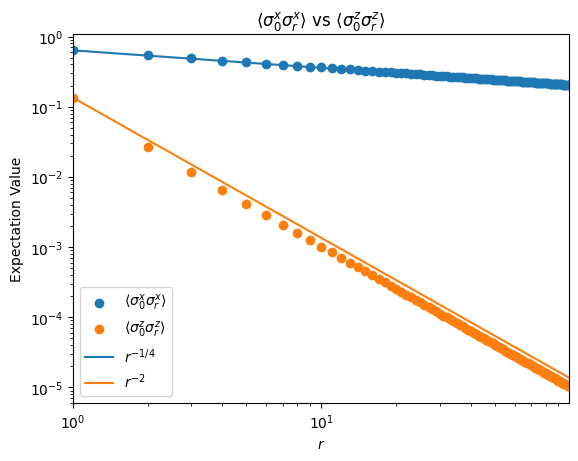

In [18]:
scatter(r,xx,label=r"$\langle \sigma^x_0 \sigma^x_r \rangle$")
scatter(r,zz,label=r"$\langle \sigma^z_0 \sigma^z_r \rangle$")
plot(r,r**(-1/4)*xx[0],label=r"$r^{-1/4}$")
plot(r,r**(-2.)*zz[0],label=r"$r^{-2}$")
plt.legend()
loglog()
xlim(r[0],r[-1])
plt.title(r"$\langle \sigma^x_0 \sigma^x_r \rangle$ vs $\langle \sigma^z_0 \sigma^z_r \rangle$")
plt.xlabel(r"$r$")
plt.ylabel(r"Expectation Value")
#plt.savefig("xx_vs_zz_comparison.png")

# Compare Projectors

In [19]:
from equilibrium_critical_correlations import P_n as Px
from equilibrium_z_projectors import P_n as Pz

In [20]:
n = np.arange(1,16+1)

In [21]:
xproj = array([Px(ni) for ni in n])
zproj = array([Pz(ni) for ni in n])

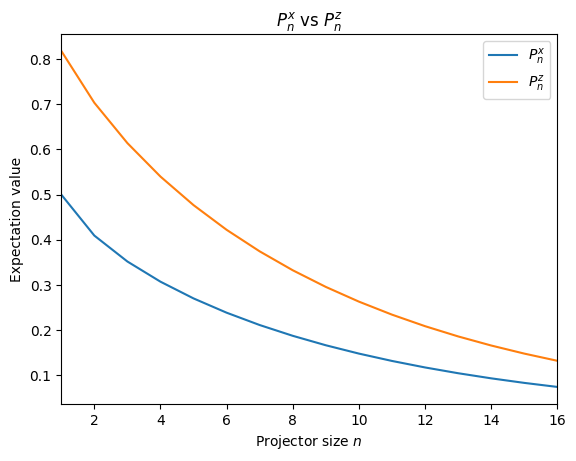

In [40]:
plot(n,xproj,label=r"$P_n^x$")
plot(n,zproj,label=r"$P_n^z$")
xlabel(r"Projector size $n$")
plt.ylabel(r"Expectation value")
plt.title(r"$P_n^x$ vs $P_n^z$")
xlim(n[0],n[-1])
#ylim(0,1)
plt.legend()
#loglog()
#plt.savefig("Px_vs_Pn_logscale.png")


# Compare Correlators of P

In [45]:
from equilibrium_critical_correlations import P_n_correlations as PPx
from equilibrium_z_projectors import P_n_correlations as PPz

In [59]:
r = np.arange(1,100+1)

In [80]:
n = 8

xxproj = array([PPx(n,li)-Px(n)**2 for li in r])
zzproj = array([PPz(n,li)-Pz(n)**2 for li in r])

(np.int64(1), np.int64(100))

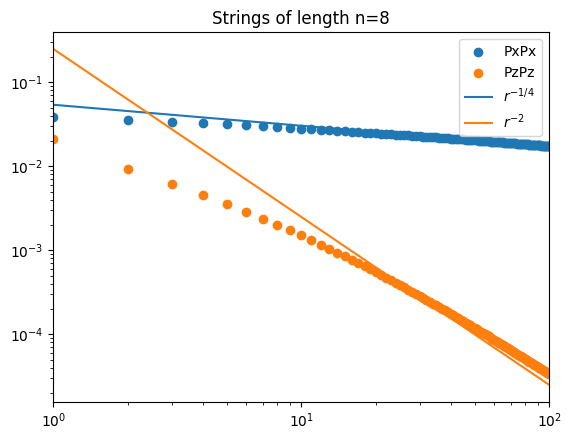

In [86]:
plt.title(f"Strings of length n={n}")
scatter(r,xxproj,label="PxPx")
scatter(r,zzproj,label="PzPz")
plot(r,r**(-1/4)/18.5,label=r"$r^{-1/4}$")
plot(r,r**(-2.)/4,label=r"$r^{-2}$")
loglog()
plt.legend()
plt.xlim(r[0],r[-1])
#plt.savefig(f"PnPn_comparison_n_{n}.png")